In [21]:
import pandas as pd

df = pd.read_csv("../data/emergency_alert_dataset_120_overlap.csv")

print(df.shape)
df.head()

(120, 6)


,people_running,alarm_count,smoke_level,temperature,co_level,genuine_alert
0,1,7,69.4,69.8,48.6,1
1,1,4,67.6,58.3,52.8,1
2,1,5,79.6,80.0,55.1,1
3,1,2,58.9,58.7,50.9,1
4,1,6,77.8,32.0,71.6,1


In [22]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["genuine_alert"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   people_running  120 non-null    int64  
 1   alarm_count     120 non-null    int64  
 2   smoke_level     120 non-null    float64
 3   temperature     120 non-null    float64
 4   co_level        120 non-null    float64
 5   genuine_alert   120 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 5.8 KB
None

Missing values:
people_running    0
alarm_count       0
smoke_level       0
temperature       0
co_level          0
genuine_alert     0
dtype: int64

Target distribution:
genuine_alert
1    80
0    40
Name: count, dtype: int64


In [23]:
print(df.describe())

       people_running  alarm_count  smoke_level  temperature    co_level  \
count      120.000000   120.000000   120.000000   120.000000  120.000000   
mean         0.641667     4.750000    57.220833    50.156667   53.929167   
std          0.481521     2.497898    24.046733    14.351299   23.887479   
min          0.000000     0.000000     0.000000    21.000000    0.000000   
25%          0.000000     3.000000    42.850000    39.725000   35.850000   
50%          1.000000     5.000000    58.050000    51.000000   55.200000   
75%          1.000000     7.000000    74.350000    60.000000   71.900000   
max          1.000000    10.000000   100.000000    80.000000  100.000000   

       genuine_alert  
count     120.000000  
mean        0.666667  
std         0.473381  
min         0.000000  
25%         0.000000  
50%         1.000000  
75%         1.000000  
max         1.000000  


In [24]:
df.groupby("genuine_alert").mean(numeric_only=True)

,people_running,alarm_count,smoke_level,temperature,co_level
genuine_alert,,,,,
0,0.225,2.6750,35.98500,38.21,32.00000
1,0.850,5.7875,67.83875,56.13,64.89375


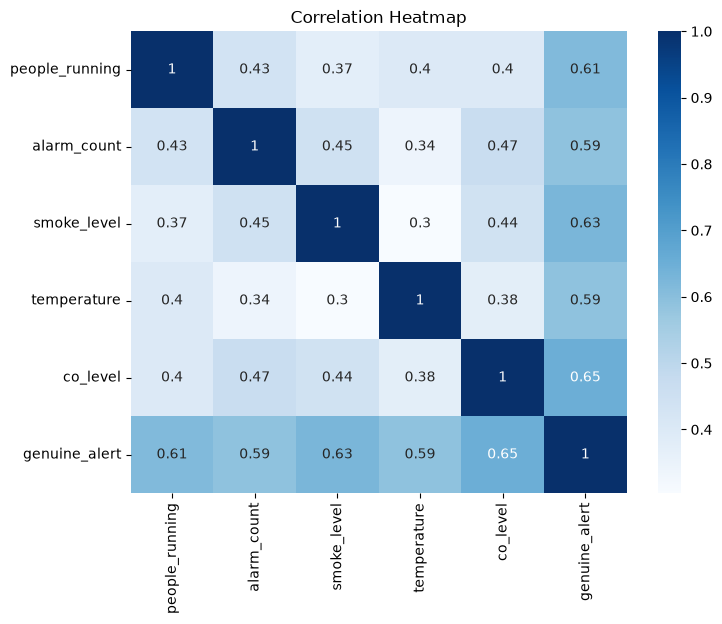

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")
plt.show()

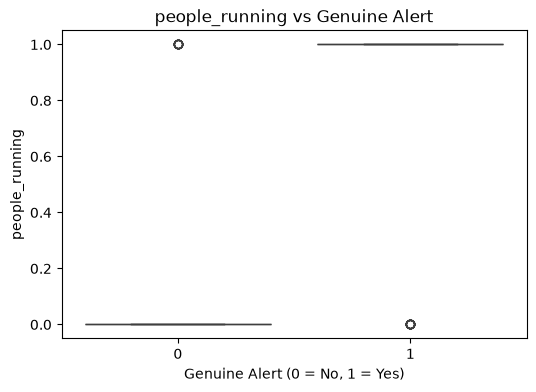

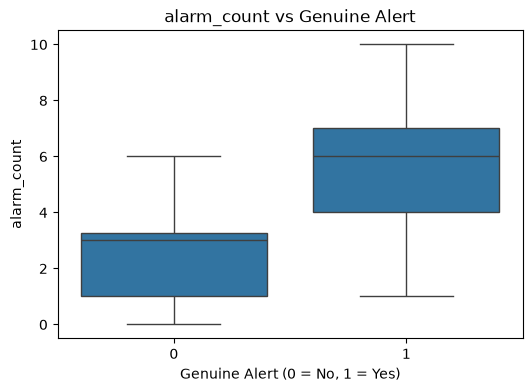

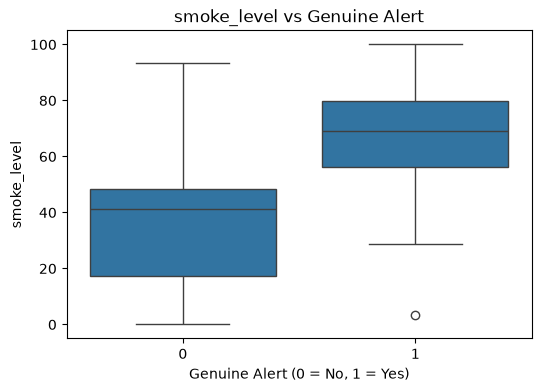

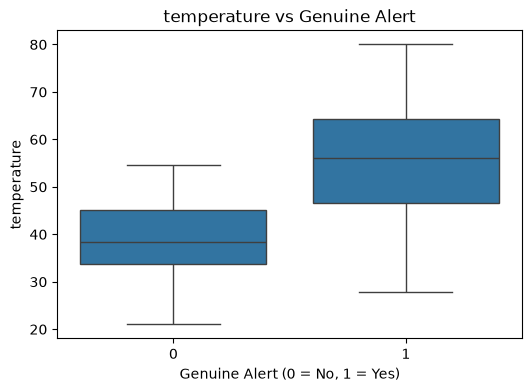

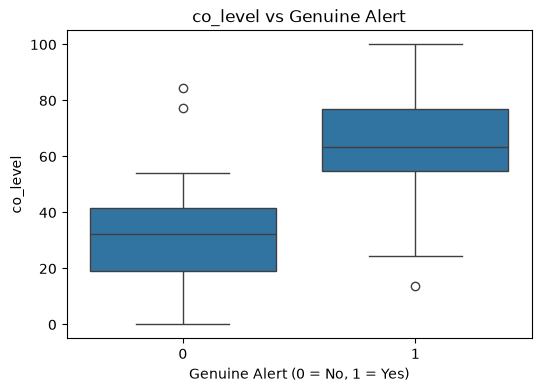

In [26]:
features = [
    "people_running",
    "alarm_count",
    "smoke_level",
    "temperature",
    "co_level"
]

for feature in features:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        x="genuine_alert",
        y=feature,
        data=df
    )

    plt.title(f"{feature} vs Genuine Alert")
    plt.xlabel("Genuine Alert (0 = No, 1 = Yes)")
    plt.show()

In [27]:
X = df[features]
y = df["genuine_alert"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 96
Testing samples: 24


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from itertools import combinations

X_train_augmented = X_train.copy()
y_train_augmented = y_train.copy()

for pair in combinations(features, 2):

    X_pair = X_train.copy()

    # Hide the 3 unavailable sensors
    for feature in features:
        if feature not in pair:
            X_pair[feature] = None

    X_train_augmented = pd.concat(
        [X_train_augmented, X_pair],
        ignore_index=True
    )

    y_train_augmented = pd.concat(
        [y_train_augmented, y_train],
        ignore_index=True
    )

model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

model.fit(
    X_train_augmented,
    y_train_augmented
)

print("Model trained successfully.")

Model trained successfully.


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

evaluation_results = {}

print("EVALUATION FOR ALL 2-SENSOR COMBINATIONS")
print("=" * 50)

for pair in combinations(features, 2):

    X_test_pair = X_test.copy()

    # Hide unavailable sensors
    for feature in features:
        if feature not in pair:
            X_test_pair[feature] = None

    predictions = model.predict(X_test_pair)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    # FAR = False Alarm Rate
    far = fp / (fp + tn)

    # FRR = False Rejection Rate
    frr = fn / (fn + tp)

    evaluation_results[pair] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "far": far,
        "frr": frr,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    print(pair)
    print(f"  Accuracy : {accuracy:.2%}")
    print(f"  Precision: {precision:.2%}")
    print(f"  Recall   : {recall:.2%}")
    print(f"  FAR      : {far:.2%}")
    print(f"  FRR      : {frr:.2%}")
    print(f"  Confusion Matrix: [[{tn}, {fp}], [{fn}, {tp}]]")
    print()

EVALUATION FOR ALL 2-SENSOR COMBINATIONS
('people_running', 'alarm_count')
  Accuracy : 87.50%
  Precision: 93.33%
  Recall   : 87.50%
  FAR      : 12.50%
  FRR      : 12.50%
  Confusion Matrix: [[7, 1], [2, 14]]

('people_running', 'smoke_level')
  Accuracy : 83.33%
  Precision: 87.50%
  Recall   : 87.50%
  FAR      : 25.00%
  FRR      : 12.50%
  Confusion Matrix: [[6, 2], [2, 14]]

('people_running', 'temperature')
  Accuracy : 83.33%
  Precision: 83.33%
  Recall   : 93.75%
  FAR      : 37.50%
  FRR      : 6.25%
  Confusion Matrix: [[5, 3], [1, 15]]

('people_running', 'co_level')
  Accuracy : 95.83%
  Precision: 94.12%
  Recall   : 100.00%
  FAR      : 12.50%
  FRR      : 0.00%
  Confusion Matrix: [[7, 1], [0, 16]]

('alarm_count', 'smoke_level')
  Accuracy : 70.83%
  Precision: 80.00%
  Recall   : 75.00%
  FAR      : 37.50%
  FRR      : 25.00%
  Confusion Matrix: [[5, 3], [4, 12]]

('alarm_count', 'temperature')
  Accuracy : 91.67%
  Precision: 88.89%
  Recall   : 100.00%
  FAR    

In [31]:
y_pred = model.predict(X_test)

print("Actual:")
print(y_test.values)

print("\nPredicted:")
print(y_pred)

Actual:
[0 0 0 1 1 1 1 0 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1]

Predicted:
[0 0 0 1 1 1 1 0 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1]


In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 8  0]
 [ 0 16]]


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

# FAR = False Alarm Rate
far = fp / (fp + tn)

# FRR = False Rejection Rate
frr = fn / (fn + tp)

print("MODEL EVALUATION")
print("=" * 40)

print(f"Accuracy  : {accuracy:.2%}")
print(f"Precision : {precision:.2%}")
print(f"Recall    : {recall:.2%}")
print(f"FAR       : {far:.2%}")
print(f"FRR       : {frr:.2%}")

print("\nConfusion Matrix")
print("=" * 40)

print("              Predicted")
print("                 0      1")
print(f"Actual  0     {tn:3d}    {fp:3d}")
print(f"        1     {fn:3d}    {tp:3d}")

MODEL EVALUATION
Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
FAR       : 0.00%
FRR       : 0.00%

Confusion Matrix
              Predicted
                 0      1
Actual  0       8      0
        1       0     16


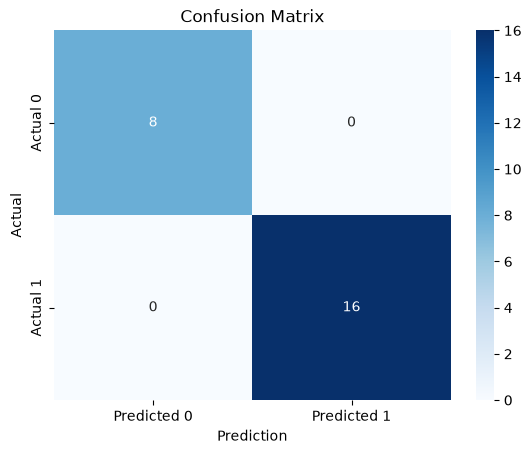

In [34]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
normal_scenario = pd.DataFrame([{
    "people_running": 0,
    "alarm_count": 1,
    "smoke_level": 10,
    "temperature": 25,
    "co_level": 8
}])

prediction = model.predict(normal_scenario)[0]
probability = model.predict_proba(normal_scenario)[0, 1]

print("Prediction:", prediction)
print("Emergency probability:", probability)

Prediction: 0
Emergency probability: 4.3975441232065694e-07


In [36]:
new_scenario = pd.DataFrame([{
    "people_running": 1,
    "alarm_count": 6,
    "smoke_level": 79,
    "temperature": 61,
    "co_level": 76
}])

prediction = model.predict(new_scenario)[0]
probability = model.predict_proba(new_scenario)[0, 1]

print("Prediction:", prediction)
print("Emergency probability:", probability)

Prediction: 1
Emergency probability: 0.9999586105375302


In [37]:
two_feature_input = pd.DataFrame([{
    "people_running": 1,
    "alarm_count": 6,
    "smoke_level": None,
    "temperature": None,
    "co_level": None
}])

prediction = model.predict(two_feature_input)[0]

print("Prediction:", prediction)

Prediction: 1


In [38]:
def process_event(event):

    features = [
        "people_running",
        "alarm_count",
        "smoke_level",
        "temperature",
        "co_level"
    ]

    # Find which sensors were provided
    available_features = [
        feature
        for feature in features
        if feature in event and event[feature] is not None
    ]

    # At least 2 sensors are required
    if len(available_features) < 2:
        raise ValueError(
            "At least 2 sensor features are required."
        )

    # Create input with all 5 columns
    # Missing sensors are represented by None
    input_data = pd.DataFrame([{
        feature: event.get(feature, None)
        for feature in features
    }])

    # Make prediction
    prediction = model.predict(input_data)[0]

    print("Available sensors:", available_features)
    print("Prediction:", prediction)

    # Emergency detected
    if prediction == 1:

        emergency_message = (
            "EMERGENCY ALERT: Possible genuine emergency detected. "
        )

        for feature in available_features:
            emergency_message += (
                f"{feature}={event[feature]}, "
            )

        emergency_message = emergency_message.rstrip(", ") + "."

        print("\nMessage ready for encryption:")
        print(emergency_message)

        return emergency_message

    # No emergency
    else:

        print("No emergency message created.")

        return None

In [39]:
process_event({
    "people_running": 1,
    "alarm_count": 6
})

Available sensors: ['people_running', 'alarm_count']
Prediction: 1

Message ready for encryption:
EMERGENCY ALERT: Possible genuine emergency detected. people_running=1, alarm_count=6.


'EMERGENCY ALERT: Possible genuine emergency detected. people_running=1, alarm_count=6.'

In [40]:
process_event({
    "people_running": 1,
    "smoke_level": 75,
    "co_level": 80
})

Available sensors: ['people_running', 'smoke_level', 'co_level']
Prediction: 1

Message ready for encryption:
EMERGENCY ALERT: Possible genuine emergency detected. people_running=1, smoke_level=75, co_level=80.


'EMERGENCY ALERT: Possible genuine emergency detected. people_running=1, smoke_level=75, co_level=80.'

In [41]:
process_event({
    "alarm_count": 2,
    "smoke_level": 30,
    "temperature": 35
})

Available sensors: ['alarm_count', 'smoke_level', 'temperature']
Prediction: 0
No emergency message created.


In [42]:
process_event({
    "people_running": 0,
    "alarm_count": 1,
    "smoke_level": 15,
    "temperature": 25
})

Available sensors: ['people_running', 'alarm_count', 'smoke_level', 'temperature']
Prediction: 0
No emergency message created.
